# Programming and Critical Analysis
## Data loading

In [43]:
from sklearn import metrics
import pandas as pd, numpy as np, math
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv("rent.csv")
df.head()

,bathrooms,bedrooms,price,longitude,latitude,interest_level
0,1.5,3,3000,-73.9425,40.7145,2
1,1.0,2,5465,-73.9667,40.7947,1
2,1.0,1,2850,-74.0018,40.7388,3
3,1.0,1,3275,-73.9677,40.7539,1
4,1.0,4,3350,-73.9493,40.8241,1


In [45]:
# splitting the data set into inputs (X) and target (y): 
# we want to predict price based on location and house specs
X = df.drop(df.columns[[2,5]], axis=1)  
y = df.iloc[:, 2]

X.head()

,bathrooms,bedrooms,longitude,latitude
0,1.5,3,-73.9425,40.7145
1,1.0,2,-73.9667,40.7947
2,1.0,1,-74.0018,40.7388
3,1.0,1,-73.9677,40.7539
4,1.0,4,-73.9493,40.8241


### 5. Manual training and cross validation function
- Linear Regression
- MLP Regresor, 2 hidden layers, 5 neurons each, no activation functions
- MLP Regressor, 2 hidden layers, 5 neurons each, ReLU activation function

We do a manual training for each regressor for 5 different random states, which is not exactly a 5-fold cross validaton, in effort to check if it would yield drastically different results from the cross validation function.

In [46]:
mae_lr_manual = []
mae_mlp_manual = []
mae_mlp_relu_manual = []
for i in range(5):
    # splitting training and testing data (70/30)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=i)

    # training linear regression model
    lr = LinearRegression()
    lr_reg = lr.fit(X_train, y_train)
    # prediction on test
    pred_test_lr= lr_reg.predict(X_test)
    # error from manual cross validation
    mae_lr_manual.append(mean_absolute_error(y_test, pred_test_lr))
    #print("R2 (manual LR):",metrics.r2_score(y_test, pred_test_lr))

    # same for MLP Regressor
    mlp = MLPRegressor(hidden_layer_sizes=(5, 5), activation='identity', solver='lbfgs', random_state=i)
    mlp_reg = mlp.fit(X_train, y_train)
    pred_test_mlp = mlp_reg.predict(X_test)
    mae_mlp_manual.append(mean_absolute_error(y_test, pred_test_mlp))

    # same for MLP, Relu activation function Regressor
    mlp_relu = MLPRegressor(hidden_layer_sizes=(5, 5), activation='relu', max_iter = 1000, random_state=i)
    mlp_relu_reg = mlp_relu.fit(X_train, y_train)
    pred_test_mlp_relu = mlp_relu_reg.predict(X_test)
    mae_mlp_relu_manual.append(mean_absolute_error(y_test, pred_test_mlp_relu))

# error from cross validation function
regressor = LinearRegression()
mae_lr = -(cross_val_score(regressor, X, y, cv=5, scoring='neg_mean_absolute_error'))
print("MAE LR:",np.mean(mae_lr))
regressor = MLPRegressor(hidden_layer_sizes=(5, 5), activation='identity', solver='lbfgs', random_state=1)
mae_mlp = -(cross_val_score(regressor, X, y, cv=5, scoring='neg_mean_absolute_error'))
print("MAE MLP:",np.mean(mae_mlp))
regressor = MLPRegressor(hidden_layer_sizes=(5, 5), activation='relu', max_iter = 1000, random_state=1)
mae_mlp_relu = -(cross_val_score(regressor, X, y, cv=5, scoring='neg_mean_absolute_error'))
print("MAE MLP ReLU:", np.mean(mae_mlp_relu))

print('-----------------------------------------')
print("MAE LR (manual):",np.mean(mae_lr_manual))
print("MAE MLP (manual):",np.mean(mae_mlp_manual))
print("MAE MLP Relu (manual):",np.mean(mae_mlp_relu_manual))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MAE LR: 1108.6812125194785
MAE MLP: 1110.971939060185
MAE MLP ReLU: 1135.6312303101404
-----------------------------------------
MAE LR (manual): 1049.0014270815902
MAE MLP (manual): 1053.557802807703
MAE MLP Relu (manual): 1026.5045436407358


### Observation:
The manual training did only slightly better, and in both cases the MLP's are not notoriously outperforming linear regression. This may indicate that there is an issue with the data, or another unnoticed issue.

/var/folders/xg/dzcqmxlx38bddqy1sz16fqmw0000gn/T/ipykernel_1625/861497587.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


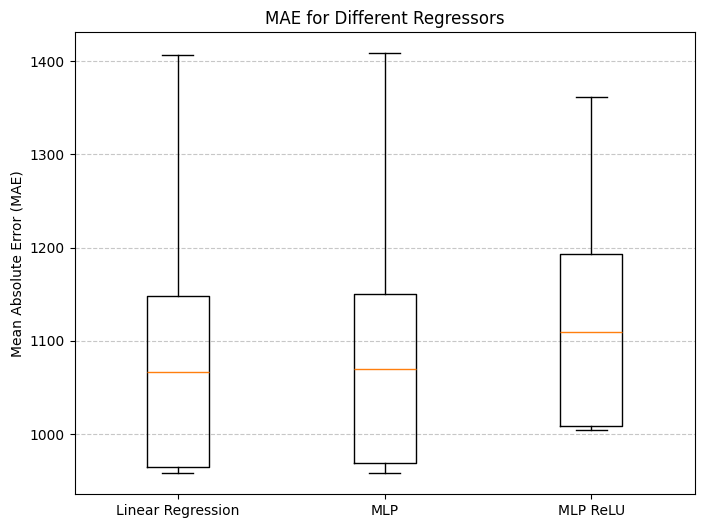

In [47]:
# Box plot
data = [mae_lr, mae_mlp, mae_mlp_relu]

labels = ['Linear Regression', 'MLP', 'MLP ReLU']

plt.figure(figsize=(8,6))
plt.boxplot(data, labels=labels)
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('MAE for Different Regressors')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 6. Linear Regression vs MLP ReLU
The linear regression is very limited for fitting data, since it relies only on linear relationships, which are uncommon for real world problems. On the other hand, the type of regression done by a Multi-Layer Perceptrons (MLP) is much more robust to fit these problems, since the activation functions, such as ReLU, introduce non-linearity. An MLP Regressor without an activation function is simply a convolution of multiple linear regressions.

By looking at the box plot, the difference in performance is not significant, perphaps because of data characteristics that were difficult to fit by the MLP regressors.

### 7. Loss Curves (MLP ReLU)

Fold 1: Train samples: 39481, Test samples: 9871


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 2: Train samples: 39481, Test samples: 9871


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 3: Train samples: 39482, Test samples: 9870


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 4: Train samples: 39482, Test samples: 9870


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 5: Train samples: 39482, Test samples: 9870


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


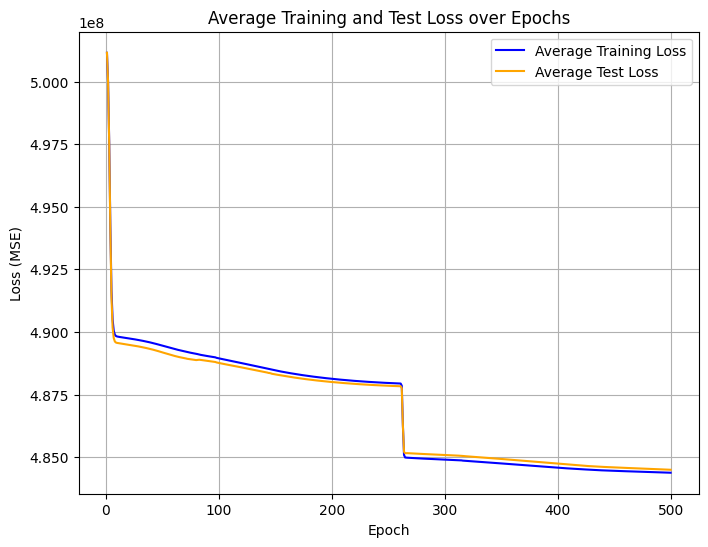

In [48]:
train_losses = []
test_losses = []

# KFold object
kf = KFold(n_splits=5, shuffle=True, random_state=33)

for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}: Train samples: {len(train_index)}, Test samples: {len(test_index)}")
    
    # split data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]


    # MLP ReLU with new solver (Adam) for weight update and 1 iteration
    mlp_relu = MLPRegressor(hidden_layer_sizes=(5, 5), activation='relu', solver='adam', max_iter=1, warm_start=True, random_state=fold)
    
    train_losses_fold = []
    test_losses_fold = []
    
    # epochs loop: track each iteration
    n_epochs = 500
    for epoch in range(n_epochs):
        if epoch == 0:
            mlp_relu.fit(X_train, y_train)
        else:
            mlp_relu.partial_fit(X_train, y_train)
        
        # training loss (MSE)
        train_pred = mlp_relu.predict(X_train)
        train_loss = mean_squared_error(y_train, train_pred)
        train_losses_fold.append(train_loss)
        
        # test loss (MSE)
        test_pred = mlp_relu.predict(X_test)
        test_loss = mean_squared_error(y_test, test_pred)
        test_losses_fold.append(test_loss)
    
    train_losses.append(train_losses_fold)
    test_losses.append(test_losses_fold)

# plot of losses
train_losses = np.array(train_losses)
test_losses = np.array(test_losses)

avg_train_loss = np.mean(train_losses, axis=0)
avg_test_loss = np.mean(test_losses, axis=0)

plt.figure(figsize=(8, 6))
epochs = np.arange(1, len(avg_train_loss) + 1)

plt.plot(epochs, avg_train_loss, label='Average Training Loss', color='blue')
plt.plot(epochs, avg_test_loss, label='Average Test Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Average Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()



### Overfitting or underfitting?
Even though the curve of the graph looks promissing as the error decreases with the number of epochs, the order of magnitude of error cannot be ignored to assess the quality of the model. The y-axis shows the mean squared error (MSE) which is of the order of 10^8, which means the error is of the order of 10^4. This error is very high considering the range of values for our target variable, prices. 

Thus, even though the curve could show a well generalized model, as both train and test loss curves decrease, the dimension of the error shows the model is still not trained enough. Therefore, it is still underfitted.